ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](img/step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")


## 1. Load Dataset

In [31]:
df = pd.read_csv("Smartphone_Usage_Productivity_Dataset_50000.csv")
df.head(10)

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9
5,U6,32,Female,Student,Android,10.9,4.2,9,6.3,7,34,5,3.6
6,U7,26,Male,Student,iOS,5.6,6.1,8,6.7,3,5,3,2.9
7,U8,24,Male,Freelancer,iOS,8.5,1.9,4,7.8,3,6,6,12.8
8,U9,52,Female,Business Owner,Android,9.4,2.5,3,6.4,4,17,3,3.1
9,U10,23,Female,Student,iOS,2.8,1.1,1,4.5,2,7,0,2.7


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Date` should be datetime
- `Revenue` should be numeric

In [7]:
df.dtypes

User_ID                       object
Age                            int64
Gender                        object
Occupation                    object
Device_Type                   object
Daily_Phone_Hours            float64
Social_Media_Hours           float64
Work_Productivity_Score        int64
Sleep_Hours                  float64
Stress_Level                   int64
App_Usage_Count                int64
Caffeine_Intake_Cups           int64
Weekend_Screen_Time_Hours    float64
dtype: object

All types are correct

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usag

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [8]:
df.isna().sum()

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?

Since our dataset has no missing values, we introduce artificial ones *for learning purposes*.

we will be running this line:

df_missing = df.copy()
### Introducing missing values in 'Daily_Phone_Hours'
df_missing.loc[0:5, 'Daily_Phone_Hours'] = np.nan
df_missing.isna().sum()

In [47]:
df_missing = df.copy()
df_missing.loc[0:5, 'Daily_Phone_Hours'] = np.nan
df_missing.isna().sum()

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            6
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

In [48]:
print("Original shape: ", df.shape)
print("After introducing missing values: ", df_missing.shape)

Original shape:  (50000, 13)
After introducing missing values:  (50000, 13)


### Strategy 3: Median Imputation

![median_formula_2.png](img/median_formula_2.png)
The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [50]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['Daily_Phone_Hours'].median()
df_imputed_median['Daily_Phone_Hours'] = df_imputed_median['Daily_Phone_Hours'].fillna(median_value)

df_imputed_median.isna().sum()

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.

![IQR.png](img/IQR.png)

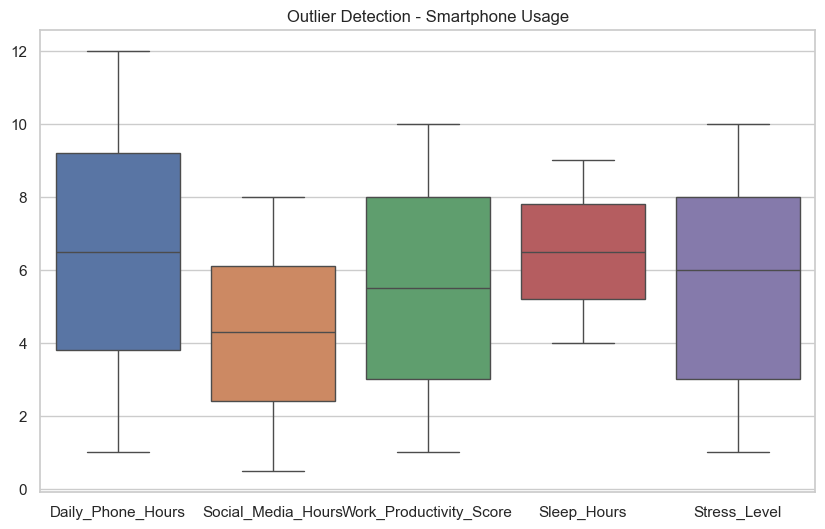

In [55]:
plt.figure(figsize=(10,6))

# Visualizing major numeric columns to see outliers
sns.boxplot(data=df_imputed_median[[
    'Daily_Phone_Hours', 
    'Social_Media_Hours', 
    'Work_Productivity_Score', 
    'Sleep_Hours', 
    'Stress_Level'
]])

plt.title("Outlier Detection - Smartphone Usage")
plt.show()

Points outside the whiskers represent potential outliers.
These extreme revenue values may influence model predictions.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [57]:
# Select only numeric columns
numeric_df = df_imputed_median.select_dtypes(include=[np.number])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1


multiplier = 0.5 

outlier_condition = ((numeric_df < (Q1 - multiplier * IQR)) | (numeric_df > (Q3 + multiplier * IQR))).any(axis=1)

outliers = df_imputed_median[outlier_condition]
print(f"Outliers detected with multiplier {multiplier}:", outliers.shape[0])

Outliers detected with multiplier 0.5: 1641


The output displays records considered extreme based on statistical boundaries.
These may be valid high-value transactions or potential data errors.

### Remove Outliers
We remove values outside the acceptable range.

Original dataset size: (50000, 13)
Dataset size after removing outliers: (48359, 13)


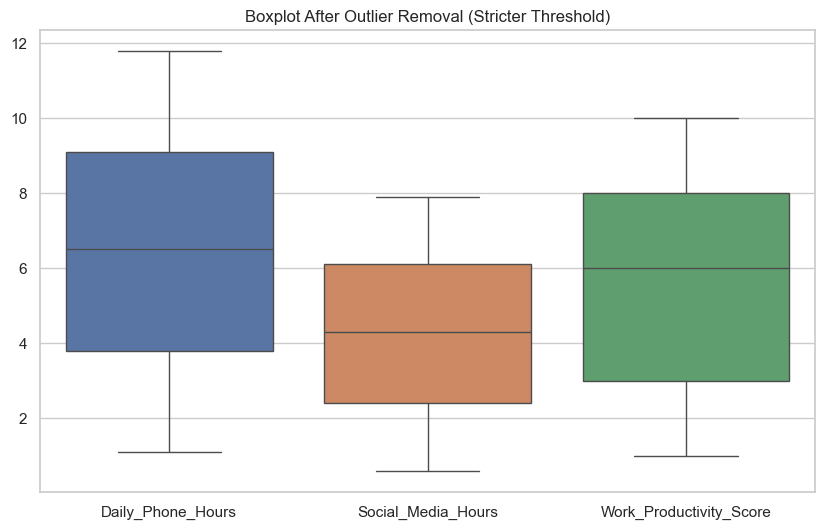

In [58]:
df_no_outliers = df_imputed_median[~outlier_condition]

print("Original dataset size:", df_imputed_median.shape)
print("Dataset size after removing outliers:", df_no_outliers.shape)

# Quick check to see the change
plt.figure(figsize=(10,6))
sns.boxplot(data=df_no_outliers[[
    'Daily_Phone_Hours', 
    'Social_Media_Hours', 
    'Work_Productivity_Score'
]])
plt.title("Boxplot After Outlier Removal (Stricter Threshold)")
plt.show()

The dataset size is slightly reduced.
Removing outliers reduces distortion but may also remove important rare events.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world events.  
For example, in a sales dataset, a very large transaction might correspond to a bulk corporate order or a seasonal promotion.  

If we remove such values blindly, we may lose valuable information and bias the analysis.

Before removing outliers, we should always ask:
- Is this value a data entry mistake?
- Or is it a valid but rare observation?

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

![percentile.png](img/percentile.png)

In [47]:
lower_cap = df['Amount'].quantile(0.05)
upper_cap = df['Amount'].quantile(0.95)

df_capped = df.copy()
df_capped['Amount'] = df_capped['Amount'].clip(lower_cap, upper_cap)

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

It works using the formula:
![min_max.png](img/min_max.png)

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [60]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Identify numerical columns to normalize
numeric_cols = df_no_outliers.select_dtypes(include=['int64','float64']).columns

df_norm = df_no_outliers.copy()
df_norm[numeric_cols] = scaler.fit_transform(df_norm[numeric_cols])

print("Data after Min-Max Normalization (0-1):")
df_norm[numeric_cols].head()

Data after Min-Max Normalization (0-1):


,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,0.952381,0.504673,0.835616,0.555556,0.96,0.333333,0.672727,0.166667,0.558333
1,0.166667,0.504673,0.123288,0.444444,0.48,0.000000,0.836364,0.500000,0.258333
2,0.023810,0.504673,0.698630,0.444444,1.00,0.333333,0.163636,0.833333,0.358333
3,0.404762,0.504673,0.260274,0.111111,0.34,0.222222,0.563636,1.000000,0.900000
4,0.357143,0.504673,0.095890,0.333333,0.34,0.222222,0.581818,0.833333,0.658333


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does NOT change the relative relationships between data points.
If one transaction originally had higher revenue than another, it will still have a higher normalized value.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![zscore.png](img/zscore.png)

This method keeps the shape of the distribution but rescales it around zero.

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


important_cols = ['Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level']

df_std = df_no_outliers.copy()
df_std[important_cols] = scaler.fit_transform(df_no_outliers[important_cols])

print("Standardized the important features:")
df_std[important_cols].head()

Standardized the important features:


,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level
0,0.01406,1.141677,0.171418,1.589503,-0.523869
1,0.01406,-1.298338,-0.176373,-0.067373,-1.568389
2,0.01406,0.672444,-0.176373,1.727576,-0.523869
3,0.01406,-0.829105,-1.219744,-0.550629,-0.872042
4,0.01406,-1.392185,-0.524163,-0.550629,-0.872042


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful 
because we can combine correlated features into fewer components.

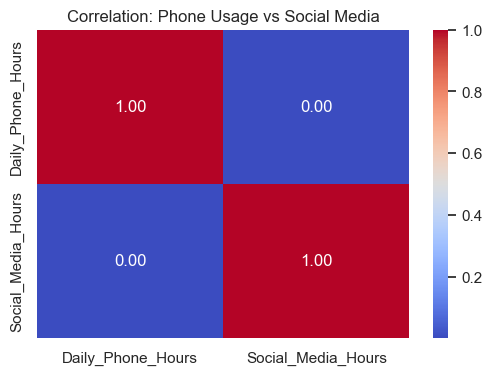

In [69]:
plt.figure(figsize=(6,4))

# Correlating only two specific columns
correlation_pair = ['Daily_Phone_Hours', 'Social_Media_Hours']
sns.heatmap(df_std[correlation_pair].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation: Phone Usage vs Social Media")
plt.show()

The heatmap shows a correlation of near 0 between Daily Phone Hours and Social Media Hours. This indicates that in this specific dataset, these behaviors are independent of one another. Consequently, PCA is less effective at reducing dimensionality because there is no redundant information to combine.

Since PCA is most useful when features are strongly correlated, 
the benefit of dimensionality reduction in this case may be limited.

Therefore, applying PCA here is mainly for demonstration purposes rather than necessity.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Amount  
X2 = Boxes Shipped  

If we plot the data points, they may look like this:

              X2
               |
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1

Notice that the points follow a diagonal pattern.
This means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.

That direction becomes **Principal Component 1 (PC1)**.

              X2
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1
                    \
                     \
                      \
                       \
                        → PC1 (maximum variance direction)

PC2 is the direction perpendicular to PC1.

If most of the variation is along PC1,
then PC1 alone captures most of the dataset’s information.

In that case, we can reduce:

2 features → 1 feature (PC1)

while keeping most of the variance.

In [70]:
from sklearn.decomposition import PCA

# Using n_components=2 to reduce the data to a 2D space
pca = PCA(n_components=2)

principal_components = pca.fit_transform(df_std[numeric_cols])

pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1','PC2']
)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print(f"Total variance captured by 2 components: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Explained Variance Ratio: [0.59779987 0.35401494]
Total variance captured by 2 components: 95.18%


The `Explained Variance Ratio` indicates how much of the total information (variance) is captured by each principal component.

For example:
- If PC1 explains 85% of the variance, it means that one new feature already summarizes most of the dataset's information.
- If PC1 and PC2 together explain nearly 100%, then very little information is lost.

When most of the variance is captured by fewer components, dimensionality reduction is considered effective.

This helps simplify models, reduce computational cost, and sometimes improve generalization performance.

In [71]:
# # In addition to the heatmap, we can visualize the relationship between two features using a scatter plot. 
# # A scatter plot allows us to observe whether the features exhibit a linear pattern, meaning whether they increase or decrease together in a consistent way.


# plt.figure(figsize=(6,4))
# plt.scatter(df_standardized['Amount'], df_standardized['Boxes Shipped'])
# plt.xlabel("Amount (Standardized)")
# plt.ylabel("Boxes Shipped (Standardized)")
# plt.title("Scatter Plot: Amount vs Boxes Shipped")
# plt.show()

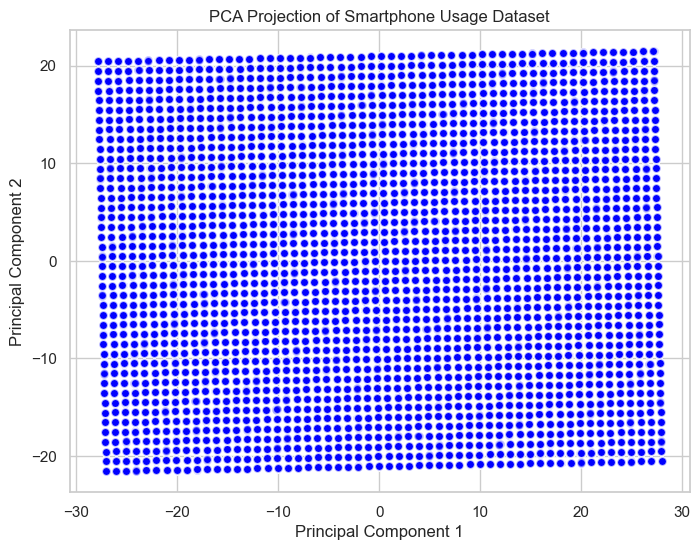

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5, c='blue', edgecolors='w')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Smartphone Usage Dataset")

plt.show()

Principal Component Analysis (PCA) was used to reduce the dimensionality of the behavioral features.

The correlation heatmap showed values near zero, indicating that features like Social_Media_Hours and Daily_Phone_Hours are independent in this dataset. Because the features do not share redundant information (low correlation), the Explained Variance is spread almost equally across the principal components. This means that no single component can capture the majority of the information; instead, each component represents a unique, independent dimension of smartphone usage behavior. The PCA projection (scatter plot) shows a uniform cloud, further confirming that user behaviors in this dataset are diverse and not tightly clustered around a single trend.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of Assignment 2